<a href="https://colab.research.google.com/github/sanjay149-aids/Gen-AI_Lab-AD23633/blob/main/Exp_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch: 1 D Loss: 0.10435178875923157 G Loss: 3.3198916912078857
Epoch: 2 D Loss: 0.16739574074745178 G Loss: 3.1889841556549072
Epoch: 3 D Loss: 0.04528094083070755 G Loss: 3.846283197402954
Epoch: 4 D Loss: 0.05088905245065689 G Loss: 3.8120405673980713
Epoch: 5 D Loss: 0.17457307875156403 G Loss: 3.176283359527588
Epoch: 6 D Loss: 0.1975710093975067 G Loss: 3.7346978187561035
Epoch: 7 D Loss: 0.3798260986804962 G Loss: 3.000825881958008
Epoch: 8 D Loss: 0.39112067222595215 G Loss: 3.1067862510681152
Epoch: 9 D Loss: 0.23819918930530548 G Loss: 2.9052534103393555
Epoch: 10 D Loss: 0.18369479477405548 G Loss: 3.5239920616149902


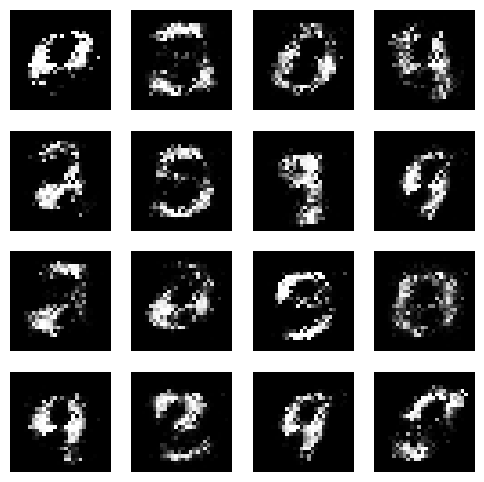

In [1]:
# @title Exp_3
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

# Load the MNIST dataset
(x_train, _), (_, _) = keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_train = x_train.reshape(-1, 28, 28, 1)
batch_size = 64
noise_dim = 100
epochs = 10
dataset = tf.data.Dataset.from_tensor_slices(x_train)
dataset = dataset.shuffle(60000).batch(batch_size)
generator = keras.Sequential([
    keras.layers.Dense(128, activation="relu", input_shape=(noise_dim,)),
    keras.layers.Dense(784, activation="sigmoid"),
    keras.layers.Reshape((28,28,1))
])
discriminator = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28,1)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")
])
loss_fn = keras.losses.BinaryCrossentropy()

g_optimizer = keras.optimizers.Adam(0.0002)
d_optimizer = keras.optimizers.Adam(0.0002)
for epoch in range(epochs):

    for real_images in dataset:

        batch_size_now = real_images.shape[0]

        real_labels = tf.ones((batch_size_now,1))
        fake_labels = tf.zeros((batch_size_now,1))

        # Generate fake images
        noise = tf.random.normal((batch_size_now, noise_dim))
        fake_images = generator(noise)

        # Train Discriminator
        with tf.GradientTape() as tape:

            real_output = discriminator(real_images)
            fake_output = discriminator(fake_images)

            real_loss = loss_fn(real_labels, real_output)
            fake_loss = loss_fn(fake_labels, fake_output)

            d_loss = real_loss + fake_loss

        grads = tape.gradient(d_loss, discriminator.trainable_variables)
        d_optimizer.apply_gradients(zip(grads, discriminator.trainable_variables))


        # Train Generator
        noise = tf.random.normal((batch_size_now, noise_dim))

        with tf.GradientTape() as tape:

            fake_images = generator(noise)
            output = discriminator(fake_images)

            g_loss = loss_fn(real_labels, output)

        grads = tape.gradient(g_loss, generator.trainable_variables)
        g_optimizer.apply_gradients(zip(grads, generator.trainable_variables))

    print("Epoch:", epoch+1, "D Loss:", float(d_loss), "G Loss:", float(g_loss))
noise = tf.random.normal((16, noise_dim))
generated_images = generator(noise)
fig, axes = plt.subplots(4,4, figsize=(6,6))

for i, ax in enumerate(axes.flat):
    ax.imshow(generated_images[i,:,:,0], cmap="gray")
    ax.axis("off")

plt.show()